# SIREN-256: Cocycle Flow vs Plain ODE vs BrainODE

Read-only visualization of the completed held-out test evaluations for the strict no-MCI, QC-passed left-structure cohort. **Cocycle Flow** is the selected full-256D direct transport trained with the geometry curriculum (`pca_parity_full_flow_v2_geometry_curriculum`); this notebook deliberately does not call it "v2 geometry curriculum" in figures or tables.

The notebook loads existing CSV/JSON evaluation artifacts only. It does not load checkpoints, run inference, write files, or select a model on the test split.

## Scope and comparability

All three runs use the same 483 test pairs, frozen SIREN surface evaluator, split, correspondence cache, and decoder. Shape and decoded-volume metrics are directly comparable. The ODE and BrainODE files predate the corrected temporal-volume-rate denominator, so this notebook intentionally does **not** compare rate MAE, predicted rates, or subject slopes across models.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    go = None
    make_subplots = None


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Open the notebook from inside the Deep3DComp repository.')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
EXPERIMENT_ROOT = REPO_ROOT / 'examples/ADNI_1_L_No_MCI_large_strict_left/task3_longitudinal_prediction/siren256_v5_flow_vs_ode_brainode_qc_v1'
VISUALIZATION_CACHE = EXPERIMENT_ROOT / 'visualization_cache'
RUN_SPECS = {
    'plain_ode': {
        'label': 'Plain ODE',
        'run': 'plain_ode_c3_matched',
        'color': '#CC79A7',
    },
    'brainode': {
        'label': 'BrainODE',
        'run': 'brainode_attention_c3_matched',
        'color': '#6C757D',
    },
    'cocycle_flow': {
        'label': 'Cocycle Flow',
        'run': 'pca_parity_full_flow_v2_geometry_curriculum',
        'color': '#0072B2',
    },
}
MODEL_ORDER = tuple(RUN_SPECS)
PAIR_KEY = ['subject_id', 'source_scan_id', 'target_scan_id']
PRIMARY_METRICS = {
    'registered_normal_mae': 'Registered normal MAE',
    'chamfer_l2_squared': 'Chamfer L2 squared',
    'assd': 'ASSD',
    'volume_relative_error': 'Volume relative error',
    'surface_area_relative_error': 'Surface-area relative error',
}


def read_json(path: Path) -> dict:
    with path.open(encoding='utf-8') as handle:
        return json.load(handle)


summaries, pair_tables, rollout_tables, slope_tables = {}, {}, {}, {}
for model, spec in RUN_SPECS.items():
    evaluation = EXPERIMENT_ROOT / 'runs' / spec['run'] / 'evaluation' / 'test'
    required = [evaluation / name for name in ('summary.json', 'per_pair_metrics.csv', 'sequence_rollout_metrics.csv', 'subject_slope_metrics.csv')]
    missing = [str(path) for path in required if not path.is_file()]
    if missing:
        raise FileNotFoundError('Missing completed evaluation artifact(s):\n' + '\n'.join(missing))
    summaries[model] = read_json(evaluation / 'summary.json')
    pair_tables[model] = pd.read_csv(evaluation / 'per_pair_metrics.csv')
    rollout_tables[model] = pd.read_csv(evaluation / 'sequence_rollout_metrics.csv')
    slope_tables[model] = pd.read_csv(evaluation / 'subject_slope_metrics.csv')

reference_pairs = set(map(tuple, pair_tables[MODEL_ORDER[0]][PAIR_KEY].astype(str).to_numpy()))
for model in MODEL_ORDER[1:]:
    current_pairs = set(map(tuple, pair_tables[model][PAIR_KEY].astype(str).to_numpy()))
    if current_pairs != reference_pairs:
        raise RuntimeError(f'{model} does not contain exactly the same test pairs.')

print(f'Loaded {len(reference_pairs)} identical test pairs for: ' + ', '.join(RUN_SPECS[model]['label'] for model in MODEL_ORDER))
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10, 'legend.fontsize': 9})
pd.set_option('display.max_columns', 50)

Loaded 483 identical test pairs for: Plain ODE, BrainODE, Cocycle Flow


## Artifact and protocol audit

The selected Cocycle Flow checkpoint must have been selected on validation before this test evaluation. The audit below exposes the exact checkpoint, evaluation pair count, and rate-definition distinction.

In [2]:
audit_rows = []
for model, spec in RUN_SPECS.items():
    summary = summaries[model]
    audit_rows.append({
        'Model': spec['label'],
        'Test pairs': summary['pair_count'],
        'Checkpoint': Path(summary['checkpoint']).name,
        'Attention contract': summary['attention_contract'],
        'Temporal-rate definition': summary.get('volume_rate_definition', 'legacy evaluator: corrected denominator unavailable'),
    })
display(pd.DataFrame(audit_rows))

selection_path = EXPERIMENT_ROOT / 'runs' / RUN_SPECS['cocycle_flow']['run'] / 'selection' / 'validation_surface_selection.json'
selection = read_json(selection_path)
display(Markdown(
    f"**Cocycle Flow validation selection:** epoch `{selection['selected_epoch']}` / "
    f"`{selection['selected_checkpoint']}`, selected on `{selection['selection_split']}` only. "
    f"Rule: {selection['selection_rule']}."
))

,Model,Test pairs,Checkpoint,Attention contract,Temporal-rate definition
0,Plain ODE,483,best.pt,not_applicable,legacy evaluator: corrected denominator unavai...
1,BrainODE,483,best.pt,one_case_one_trajectory; singleton QKV; no cro...,legacy evaluator: corrected denominator unavai...
2,Cocycle Flow,483,best.pt,not_applicable,log(decoded predicted volume / decoded source ...


**Cocycle Flow validation selection:** epoch `10` / `epoch_0010`, selected on `val` only. Rule: min decoded validation volume error subject to decoded geometry gates; no-change fallback.

## Official subject-macro test summary

These are the evaluation summaries used for paper-level claims: each subject contributes equally regardless of its number of pairs. Lower is better for every metric shown.

### All test pairs

,Registered normal MAE,Chamfer L2 squared,ASSD,Volume relative error,Surface-area relative error
Model,,,,,
Plain ODE,0.019435,0.000967,0.024912,0.081559,0.093697
BrainODE,0.018917,0.000993,0.025229,0.075000,0.076390
Cocycle Flow,0.016124,0.001005,0.025359,0.053356,0.033931


### First-to-last test pairs

,Registered normal MAE,Chamfer L2 squared,ASSD,Volume relative error,Surface-area relative error
Model,,,,,
Plain ODE,0.022518,0.001150,0.026801,0.122240,0.123672
BrainODE,0.023101,0.001113,0.026359,0.104239,0.099811
Cocycle Flow,0.018245,0.001136,0.026582,0.072892,0.041542


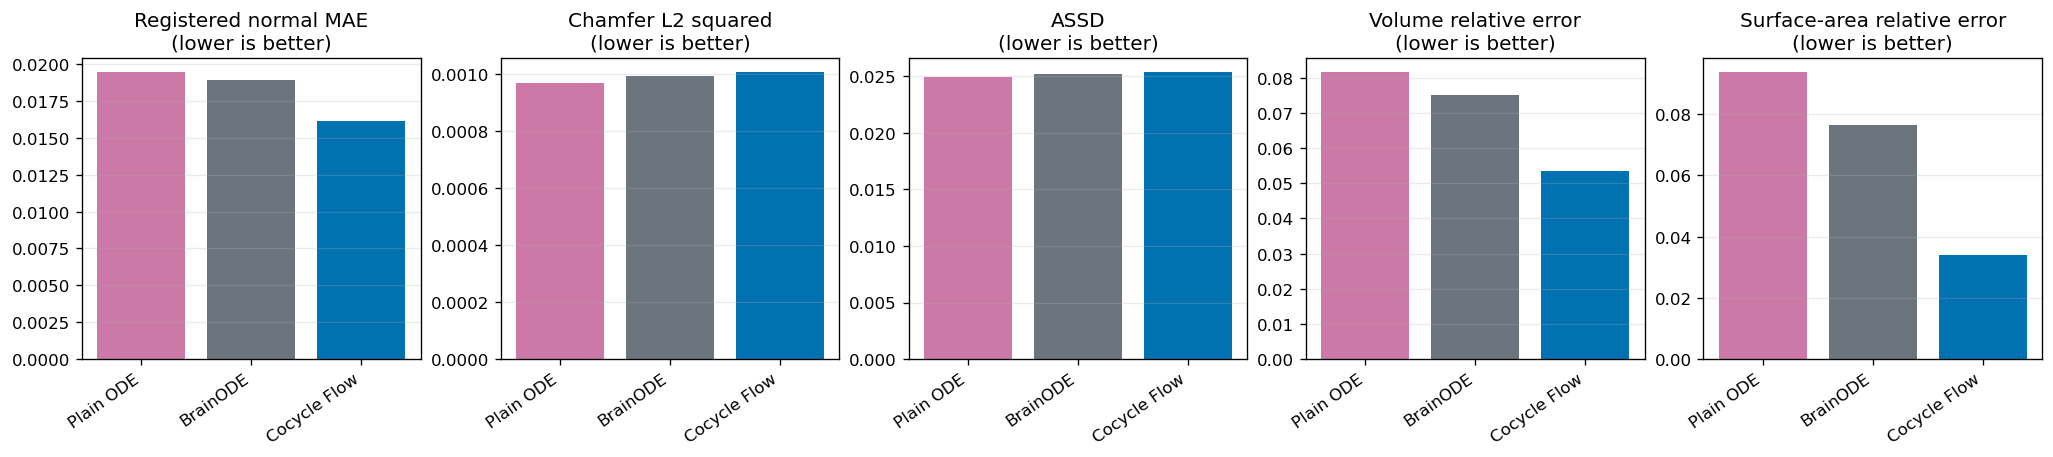

In [3]:
def macro_frame(panel: str) -> pd.DataFrame:
    rows = []
    for model, spec in RUN_SPECS.items():
        values = summaries[model]['subject_macro'][panel]
        rows.append({'Model': spec['label'], **{PRIMARY_METRICS[key]: values[key] for key in PRIMARY_METRICS}})
    return pd.DataFrame(rows).set_index('Model').loc[[RUN_SPECS[model]['label'] for model in MODEL_ORDER]]

all_subject_macro = macro_frame('all_subject_macro')
first_last_subject_macro = macro_frame('first_last_subject_macro')
display(Markdown('### All test pairs'))
display(all_subject_macro.round(6))
display(Markdown('### First-to-last test pairs'))
display(first_last_subject_macro.round(6))

fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(17, 3.7), constrained_layout=True)
for ax, metric_label in zip(axes, PRIMARY_METRICS.values()):
    values = all_subject_macro[metric_label]
    colors = [RUN_SPECS[model]['color'] for model in MODEL_ORDER]
    ax.bar(range(len(values)), values, color=colors)
    ax.set_xticks(range(len(values)), values.index, rotation=35, ha='right')
    ax.set_title(metric_label + '\n(lower is better)')
    ax.grid(axis='y', alpha=0.25)
plt.show()

## Diagnosis and follow-up-gap views

Diagnosis bars remain subject-macro summaries. Gap curves are descriptive matched-pair means, shown to inspect where errors change with follow-up duration; they are not substitute statistical tests.

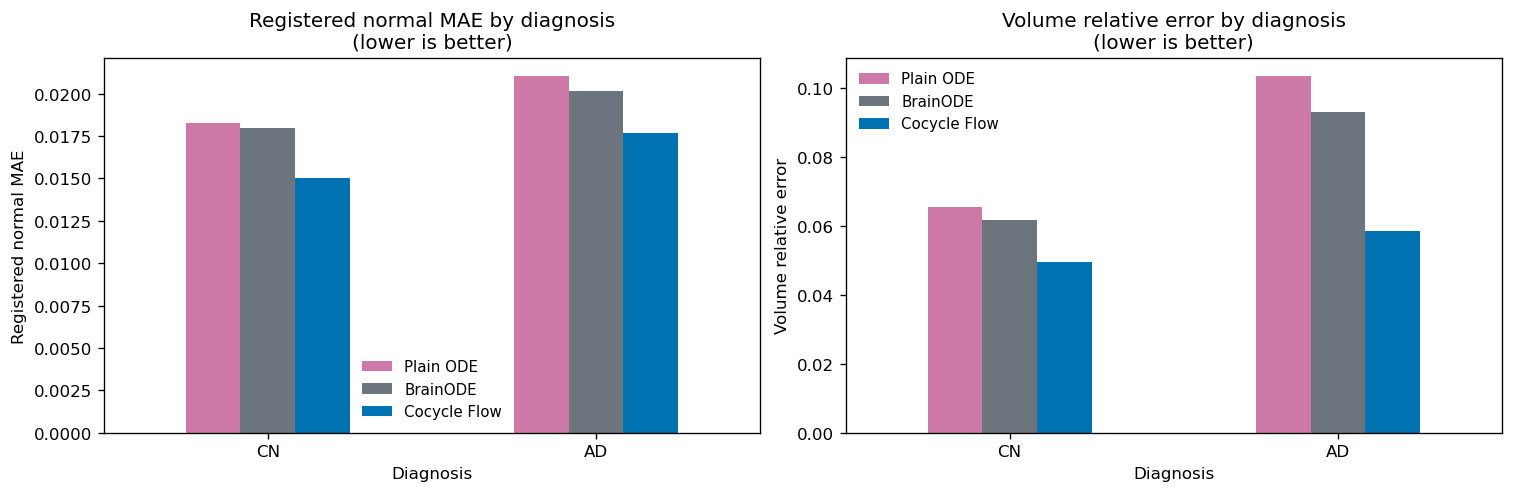

Mean                         \
Metric                 Registered normal MAE                          
Model                               BrainODE Cocycle Flow Plain ODE   
Diagnosis Gap                                                         
AD        1–2 years                 0.024539     0.021266  0.024992   
          over 2 years              0.027368     0.021828  0.027706   
          under 1 year              0.018416     0.017253  0.019254   
CN        1–2 years                 0.016887     0.014013  0.017261   
          over 2 years              0.023096     0.016426  0.022020   
          under 1 year              0.015313     0.013940  0.016099   

                                                                     \
Metric                 Volume relative error                          
Model                               BrainODE Cocycle Flow Plain ODE   
Diagnosis Gap                                                         
AD        1–2 years                 0.128379     0.066878  0.140957   
          over 2 years              0.179431     0.094960  0.199545   
          under 1 year              0.055371     0.039281  0.066913   
CN        1–2 years                 0.053989     0.038315  0.058341   
          over 2 years              0.110642     0.074141  0.128192   
          under 1 year              0.045403     0.040549  0.045742   

                                       Pairs                         \
Metric                 Registered normal MAE                          
Model                               BrainODE Cocycle Flow Plain ODE   
Diagnosis Gap                                                         
AD        1–2 years                       26           26        26   
          over 2 years                     8            8         8   
          under 1 year                    41           41        41   
CN        1–2 years                       86           86        86   
          over 2 years                   229          229       229   
          under 1 year                    93           93        93   

                                                                     
Metric                 Volume relative error                         
Model                               BrainODE Cocycle Flow Plain ODE  
Diagnosis Gap                                                        
AD        1–2 years                       26           26        26  
          over 2 years                     8            8         8  
          under 1 year                    41           41        41  
CN        1–2 years                       86           86        86  
          over 2 years                   229          229       229  
          under 1 year                    93           93        93

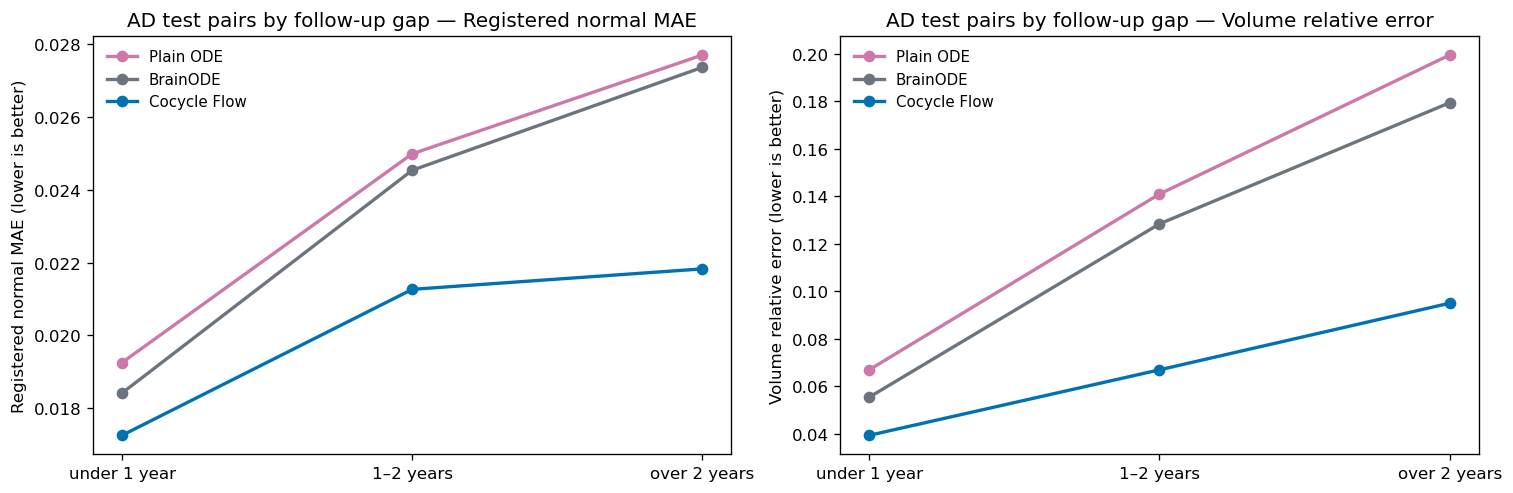

In [4]:
def diagnosis_macro(metric: str) -> pd.DataFrame:
    rows = []
    for model, spec in RUN_SPECS.items():
        for diagnosis in ('CN', 'AD'):
            rows.append({'Model': spec['label'], 'Diagnosis': diagnosis, 'value': summaries[model]['subject_macro']['by_diagnosis_subject_macro'][diagnosis][metric]})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), constrained_layout=True)
for ax, metric in zip(axes, ('registered_normal_mae', 'volume_relative_error')):
    data = diagnosis_macro(metric)
    pivot = data.pivot(index='Diagnosis', columns='Model', values='value').reindex(['CN', 'AD'])
    pivot = pivot[[RUN_SPECS[model]['label'] for model in MODEL_ORDER]]
    pivot.plot.bar(ax=ax, color=[RUN_SPECS[model]['color'] for model in MODEL_ORDER], rot=0)
    ax.set_title(PRIMARY_METRICS[metric] + ' by diagnosis\n(lower is better)')
    ax.set_ylabel(PRIMARY_METRICS[metric])
    ax.legend(frameon=False, title=None)
plt.show()

gap_order = ['under 1 year', '1–2 years', 'over 2 years']
gap_rows = []
for model, table in pair_tables.items():
    data = table.copy()
    data['gap_bin'] = pd.cut(data['gap_years'].abs(), [-np.inf, 1.0, 2.0, np.inf], labels=gap_order)
    for (diagnosis, gap_bin), group in data.groupby(['diagnosis', 'gap_bin'], observed=True):
        for metric in ('registered_normal_mae', 'volume_relative_error'):
            gap_rows.append({'Model': RUN_SPECS[model]['label'], 'Diagnosis': diagnosis, 'Gap': str(gap_bin), 'Metric': PRIMARY_METRICS[metric], 'Mean': group[metric].mean(), 'Pairs': len(group)})
gap_table = pd.DataFrame(gap_rows)
display(gap_table.pivot_table(index=['Diagnosis', 'Gap'], columns=['Metric', 'Model'], values=['Mean', 'Pairs'], aggfunc='first').round(6))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), constrained_layout=True)
for ax, metric_label in zip(axes, (PRIMARY_METRICS['registered_normal_mae'], PRIMARY_METRICS['volume_relative_error'])):
    data = gap_table.query("Diagnosis == 'AD' and Metric == @metric_label")
    for model in MODEL_ORDER:
        label = RUN_SPECS[model]['label']
        current = data[data['Model'] == label].set_index('Gap').reindex(gap_order)
        ax.plot(gap_order, current['Mean'], marker='o', linewidth=2, color=RUN_SPECS[model]['color'], label=label)
    ax.set_title('AD test pairs by follow-up gap — ' + metric_label)
    ax.set_ylabel(metric_label + ' (lower is better)')
    ax.legend(frameon=False)
plt.show()

## Matched-pair distributions

Each panel compares Cocycle Flow with one ODE on the identical source/target pairs. Points below the diagonal favour Cocycle Flow because both selected metrics are errors.

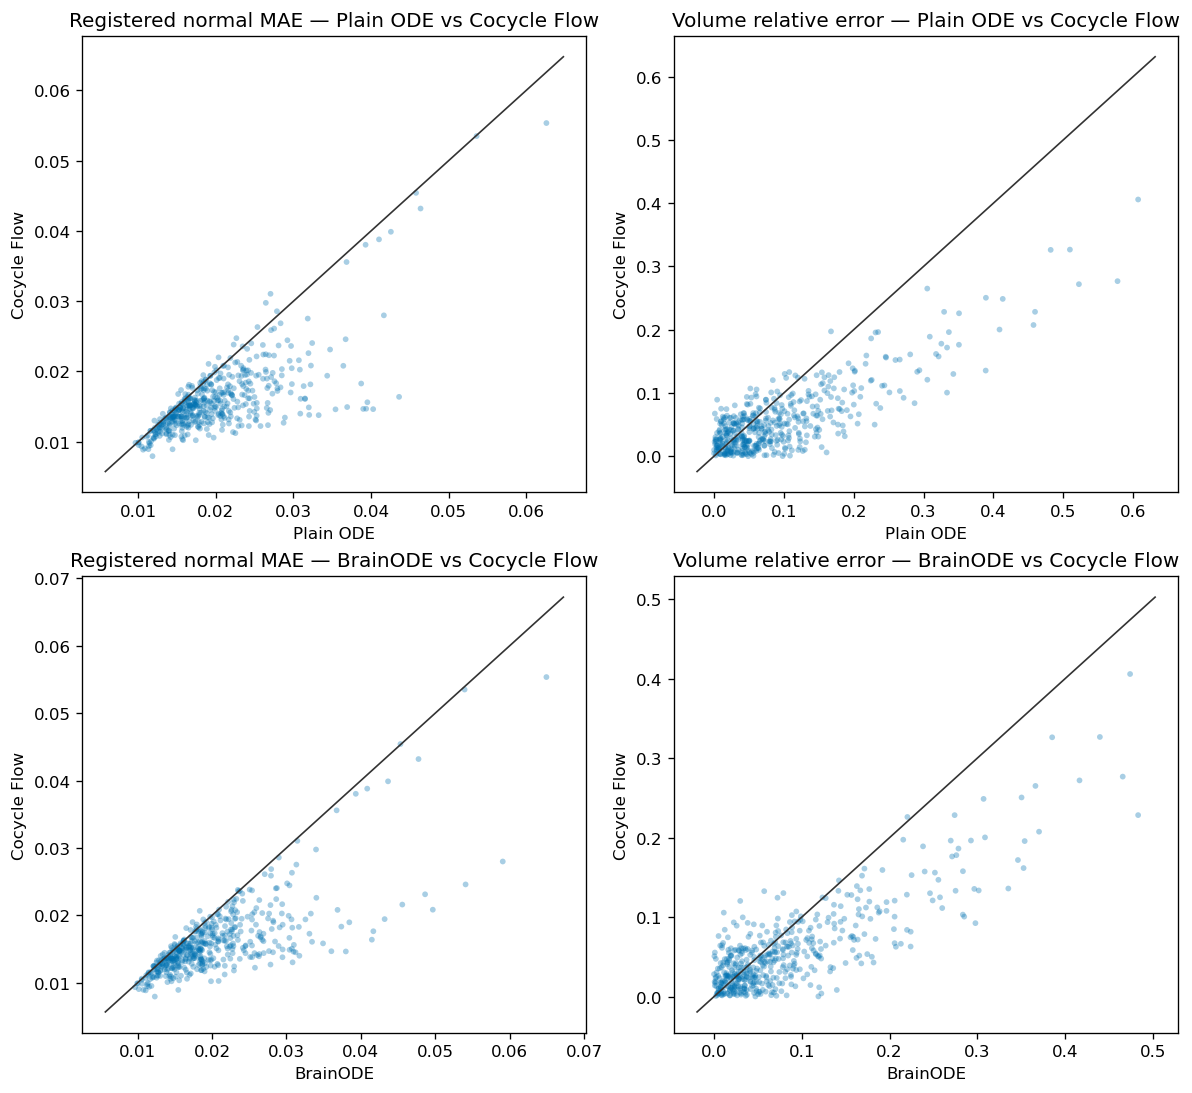

In [5]:
def paired_frame(other: str, metric: str) -> pd.DataFrame:
    left = pair_tables[other][PAIR_KEY + [metric]].copy()
    right = pair_tables['cocycle_flow'][PAIR_KEY + [metric]].copy()
    return left.merge(right, on=PAIR_KEY, suffixes=('_other', '_flow'), validate='one_to_one')

fig, axes = plt.subplots(2, 2, figsize=(9.8, 9.0), constrained_layout=True)
for row, other in enumerate(('plain_ode', 'brainode')):
    for col, metric in enumerate(('registered_normal_mae', 'volume_relative_error')):
        data = paired_frame(other, metric)
        x, y = data[f'{metric}_other'], data[f'{metric}_flow']
        low, high = min(x.min(), y.min()), max(x.max(), y.max())
        pad = max((high - low) * 0.04, 1e-8)
        ax = axes[row, col]
        ax.scatter(x, y, s=12, alpha=0.34, color=RUN_SPECS['cocycle_flow']['color'], edgecolors='none')
        ax.plot([low - pad, high + pad], [low - pad, high + pad], color='#333333', linewidth=1)
        ax.set_xlabel(RUN_SPECS[other]['label'])
        ax.set_ylabel('Cocycle Flow')
        ax.set_title(PRIMARY_METRICS[metric] + f' — {RUN_SPECS[other]["label"]} vs Cocycle Flow')
plt.show()

## Composition and rollout diagnostics

Inverse and semigroup defects measure transport composition, not anatomical accuracy. Their small values are useful only alongside the shape/volume panels above. Direct-vs-rollout is computed on subjects with at least three visits.

### Composition defects (subject macro)

,Inverse defect,Semigroup defect
Model,,
Plain ODE,4.398e-05,1.813e-06
BrainODE,1.660e-06,1.934e-08
Cocycle Flow,4.877e-10,3.190e-11


### Direct versus sequential rollout

,Subjects,Direct normal MAE,Rollout normal MAE,Rollout − direct
Model,,,,
Plain ODE,40,0.023153,0.023014,-1.384e-04
BrainODE,40,0.024232,0.024251,1.854e-05
Cocycle Flow,40,0.018861,0.018855,-5.694e-06


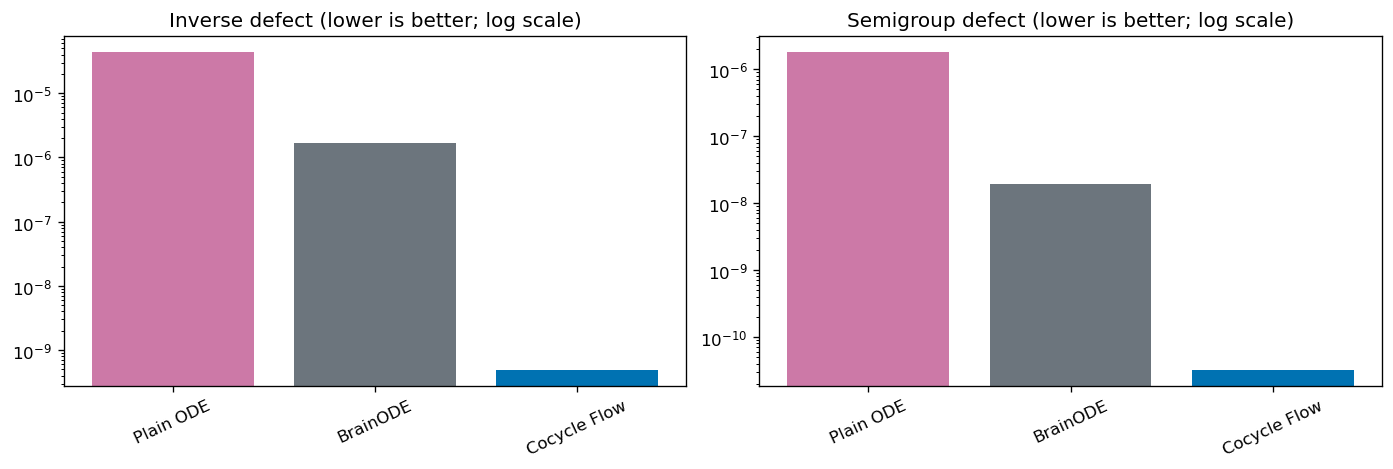

In [6]:
consistency_rows, rollout_rows = [], []
for model, spec in RUN_SPECS.items():
    macro = summaries[model]['subject_macro']['all_subject_macro']
    consistency_rows.append({'Model': spec['label'], 'Inverse defect': macro['inverse_defect'], 'Semigroup defect': macro['semigroup_defect']})
    rollout = summaries[model]['direct_vs_rollout']
    rollout_rows.append({'Model': spec['label'], 'Subjects': rollout['subjects'], 'Direct normal MAE': rollout['direct_normal_mae'], 'Rollout normal MAE': rollout['rollout_normal_mae'], 'Rollout − direct': rollout['rollout_minus_direct']})

consistency = pd.DataFrame(consistency_rows).set_index('Model')
rollout = pd.DataFrame(rollout_rows).set_index('Model')
display(Markdown('### Composition defects (subject macro)'))
display(consistency.map(lambda value: f'{value:.3e}'))
display(Markdown('### Direct versus sequential rollout'))
display(rollout.assign(**{'Direct normal MAE': rollout['Direct normal MAE'].map(lambda value: f'{value:.6f}'), 'Rollout normal MAE': rollout['Rollout normal MAE'].map(lambda value: f'{value:.6f}'), 'Rollout − direct': rollout['Rollout − direct'].map(lambda value: f'{value:.3e}')}).rename_axis('Model'))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), constrained_layout=True)
for ax, column in zip(axes, ('Inverse defect', 'Semigroup defect')):
    ax.bar(consistency.index, consistency[column], color=[RUN_SPECS[model]['color'] for model in MODEL_ORDER])
    ax.set_yscale('log')
    ax.set_title(column + ' (lower is better; log scale)')
    ax.tick_params(axis='x', rotation=25)
plt.show()

## One-time decoded-mesh cache

Run this once from the repository root before executing the mesh section. It reads the three fixed completed checkpoints and two deterministic held-out cases, writing only a new `visualization_cache/` directory. No experiment output, checkpoint, source mesh, or metric table is overwritten.

```bash
ROOT=examples/ADNI_1_L_No_MCI_large_strict_left/task3_longitudinal_prediction/siren256_v5_flow_vs_ode_brainode_qc_v1
PY=/home/jakaria/anaconda3/envs/inr_sdf/bin/python
$PY $ROOT/scripts/build_siren256_cocycle_flow_visualization_cache.py --device cuda:0
```

The cache selects one CN and one AD subject deterministically: most baseline-anchored visits, then longest follow-up, then subject ID.

## Ground-truth versus predicted volume trends

These panels use baseline-anchored test forecasts only. Ground truth is the registered target-mesh volume; every model curve is its own frozen-SIREN decoded prediction. Values are normalized to each subject's registered baseline before cohort averaging, so the panel shows change rather than group size differences.

### Contributing subjects per time bin

series                      BrainODE  Cocycle Flow  Ground truth baseline  \
diagnosis elapsed_year_bin                                                  
AD        0                       10            10                     19   
          1                       17            17                      0   
          2                       11            11                      0   
CN        0                        6             6                     27   
          1                       24            24                      0   
          2                       19            19                      0   
          3                       13            13                      0   
          4                       11            11                      0   
          5                        8             8                      0   
          6                        5             5                      0   
          7                        6             6                      0   
          8                        5             5                      0   
          10                       2             2                      0   

series                      Ground truth follow-up  Plain ODE  
diagnosis elapsed_year_bin                                     
AD        0                                     10         10  
          1                                     17         17  
          2                                     11         11  
CN        0                                      6          6  
          1                                     24         24  
          2                                     19         19  
          3                                     13         13  
          4                                     11         11  
          5                                      8          8  
          6                                      5          5  
          7                                      6          6  
          8                                      5          5  
          10                                     2          2

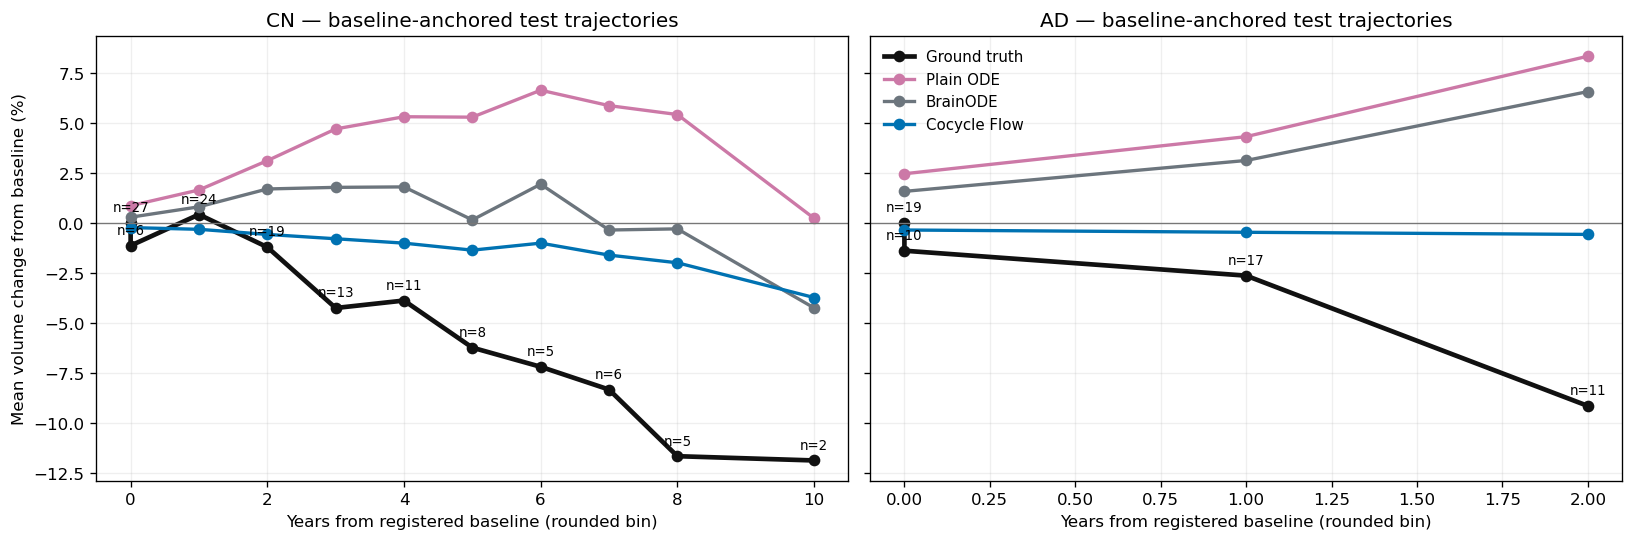

In [7]:
def canonical_id(value) -> str:
    text = str(value).strip()
    try:
        number = float(text)
    except ValueError:
        return text
    return str(int(number)) if np.isfinite(number) and number.is_integer() else text


def baseline_volume_trajectories() -> pd.DataFrame:
    reference = pair_tables['cocycle_flow'].query('source_visit_order == 0').copy()
    reference['subject_key'] = reference['subject_id'].map(canonical_id)
    source = (
        reference.sort_values(['subject_key', 'source_time'])
        .drop_duplicates('subject_key')
        [['subject_key', 'diagnosis', 'source_scan_id', 'source_volume']]
        .rename(columns={'source_volume': 'volume_mm3'})
    )
    source['elapsed_years'] = 0.0
    source['visit_order'] = 0
    source['series'] = 'Ground truth baseline'
    source['model'] = 'observed'
    target = (
        reference[['subject_key', 'diagnosis', 'target_scan_id', 'target_visit_order', 'gap_years', 'target_volume', 'source_volume']]
        .drop_duplicates(['subject_key', 'target_scan_id'])
        .rename(columns={'target_scan_id': 'scan_id', 'target_visit_order': 'visit_order', 'gap_years': 'elapsed_years', 'target_volume': 'volume_mm3'})
    )
    target['series'] = 'Ground truth follow-up'
    target['model'] = 'observed'
    frames = [source, target[['subject_key', 'diagnosis', 'scan_id', 'visit_order', 'elapsed_years', 'volume_mm3', 'series', 'model']]]
    for model, spec in RUN_SPECS.items():
        table = pair_tables[model].query('source_visit_order == 0').copy()
        table['subject_key'] = table['subject_id'].map(canonical_id)
        predicted = (
            table[['subject_key', 'diagnosis', 'target_scan_id', 'target_visit_order', 'gap_years', 'predicted_decoded_volume']]
            .drop_duplicates(['subject_key', 'target_scan_id'])
            .rename(columns={'target_scan_id': 'scan_id', 'target_visit_order': 'visit_order', 'gap_years': 'elapsed_years', 'predicted_decoded_volume': 'volume_mm3'})
        )
        predicted['series'] = spec['label']
        predicted['model'] = model
        frames.append(predicted)
    output = pd.concat(frames, ignore_index=True, sort=False)
    baseline = source[['subject_key', 'volume_mm3']].rename(columns={'volume_mm3': 'baseline_volume_mm3'})
    output = output.merge(baseline, on='subject_key', validate='many_to_one')
    output['relative_volume_change_percent'] = 100.0 * (output['volume_mm3'] / output['baseline_volume_mm3'] - 1.0)
    output['elapsed_year_bin'] = output['elapsed_years'].round().astype(int)
    return output


volume_trajectories = baseline_volume_trajectories()
subject_bin_volume = (
    volume_trajectories.groupby(['diagnosis', 'model', 'series', 'subject_key', 'elapsed_year_bin'], as_index=False)
    .agg(relative_volume_change_percent=('relative_volume_change_percent', 'mean'))
)
cohort_volume = (
    subject_bin_volume.groupby(['diagnosis', 'model', 'series', 'elapsed_year_bin'], as_index=False)
    .agg(subjects=('subject_key', 'nunique'), mean_percent_change=('relative_volume_change_percent', 'mean'))
)
display(Markdown('### Contributing subjects per time bin'))
display(cohort_volume.pivot_table(index=['diagnosis', 'elapsed_year_bin'], columns='series', values='subjects', aggfunc='first').fillna(0).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharey=True, constrained_layout=True)
for axis, diagnosis in zip(axes, ('CN', 'AD')):
    data = cohort_volume.query('diagnosis == @diagnosis')
    observed = data[data.model == 'observed'].sort_values('elapsed_year_bin')
    axis.plot(observed['elapsed_year_bin'], observed['mean_percent_change'], color='#111111', linewidth=2.8, marker='o', label='Ground truth')
    for model in MODEL_ORDER:
        current = data[data.model == model].sort_values('elapsed_year_bin')
        axis.plot(current['elapsed_year_bin'], current['mean_percent_change'], color=RUN_SPECS[model]['color'], linewidth=2, marker='o', label=RUN_SPECS[model]['label'])
    for row in observed.itertuples(index=False):
        axis.annotate(f'n={row.subjects}', (row.elapsed_year_bin, row.mean_percent_change), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8)
    axis.axhline(0, color='#777777', linewidth=0.8)
    axis.set_title(f'{diagnosis} — baseline-anchored test trajectories')
    axis.set_xlabel('Years from registered baseline (rounded bin)')
    axis.grid(alpha=0.2)
axes[0].set_ylabel('Mean volume change from baseline (%)')
axes[1].legend(frameon=False, loc='best')
plt.show()

## Representative individual volume trajectories

The same two deterministic subjects used for the 3D panels are shown here at every observed follow-up. Solid black is ground truth; coloured lines are one-step forecasts from the registered baseline to each follow-up.

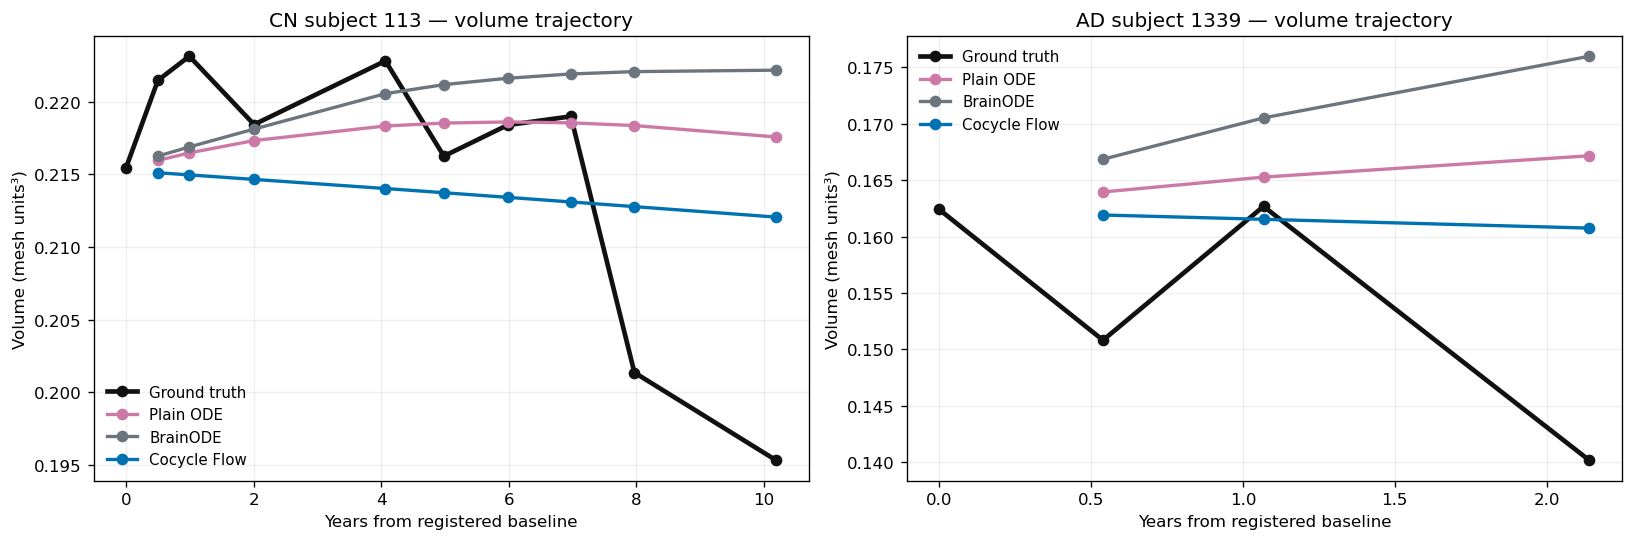

,subject_id,source_scan_id,target_scan_id,future_visits,maximum_followup_years,selection_rule
AD,1339,1339_bl_left,1339_m24_left,3,2.140999,"most baseline-anchored follow-up visits, then ..."
CN,113,113_bl_left,113_m108_left,9,10.195756,"most baseline-anchored follow-up visits, then ..."


In [8]:
selected_case_path = VISUALIZATION_CACHE / 'selected_cases.json'
if not selected_case_path.is_file():
    raise FileNotFoundError('Run the one-time visualization-cache command above before plotting selected trajectories and meshes.')
selected_cases = read_json(selected_case_path)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), constrained_layout=True)
for axis, diagnosis in zip(axes, ('CN', 'AD')):
    subject_key = canonical_id(selected_cases[diagnosis]['subject_id'])
    data = volume_trajectories.query('diagnosis == @diagnosis').copy()
    data = data[data.subject_key == subject_key].sort_values(['model', 'elapsed_years'])
    observed = data[data.model == 'observed'].sort_values('elapsed_years')
    axis.plot(observed['elapsed_years'], observed['volume_mm3'], color='#111111', linewidth=2.8, marker='o', label='Ground truth')
    for model in MODEL_ORDER:
        current = data[data.model == model].sort_values('elapsed_years')
        axis.plot(current['elapsed_years'], current['volume_mm3'], color=RUN_SPECS[model]['color'], linewidth=2, marker='o', label=RUN_SPECS[model]['label'])
    axis.set_title(f"{diagnosis} subject {selected_cases[diagnosis]['subject_id']} — volume trajectory")
    axis.set_xlabel('Years from registered baseline')
    axis.set_ylabel('Volume (mesh units³)')
    axis.grid(alpha=0.2)
    axis.legend(frameon=False)
plt.show()

display(pd.DataFrame(selected_cases).T[['subject_id', 'source_scan_id', 'target_scan_id', 'future_visits', 'maximum_followup_years', 'selection_rule']])

## Interactive 3D source, ground truth, and predicted surfaces

The source and ground-truth panels are registered meshes. Each prediction is the decoded frozen-SIREN zero-level surface from the same checkpoint evaluated in the test experiment. Prediction panels are coloured by nearest-surface distance to the registered ground-truth future mesh (yellow/red is larger error).

A correspondence-based *local change* map would be invalid here: each model prediction is independently extracted by marching cubes and therefore has different vertex topology. The notebook presents the valid decoded-surface error maps instead.

In [9]:
if go is None:
    print('Install plotly in the inr_sdf environment to render the interactive 3D mesh panels.')
else:
    mesh_path = VISUALIZATION_CACHE / 'selected_meshes.npz'
    if not mesh_path.is_file():
        raise FileNotFoundError('Run the one-time visualization-cache command above before rendering 3D meshes.')
    mesh_data = np.load(mesh_path)

    def add_surface(figure, vertices, faces, row, column, *, error=None, error_max=None):
        options = dict(x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2], i=faces[:, 0], j=faces[:, 1], k=faces[:, 2], flatshading=False, hoverinfo='skip')
        if error is None:
            options['color'] = '#D9D9D9'
        else:
            options.update(intensity=error, colorscale='Inferno', cmin=0.0, cmax=error_max, showscale=(column == 2), colorbar=dict(title='Nearest<br>error'))
        figure.add_trace(go.Mesh3d(**options), row=row, col=column)

    for diagnosis in ('CN', 'AD'):
        prefix = diagnosis.lower()
        errors = np.concatenate([mesh_data[f'{prefix}_{model}_nearest_target_error'] for model in MODEL_ORDER])
        error_max = float(np.nanpercentile(errors, 98))
        titles = ('Registered source', 'Registered ground truth future', 'Plain ODE error', 'BrainODE error', 'Cocycle Flow error', '')
        figure = make_subplots(rows=2, cols=3, specs=[[{'type': 'scene'}] * 3, [{'type': 'scene'}] * 3], subplot_titles=titles, horizontal_spacing=0.025, vertical_spacing=0.06)
        add_surface(figure, mesh_data[f'{prefix}_source_vertices'], mesh_data[f'{prefix}_source_faces'], 1, 1)
        add_surface(figure, mesh_data[f'{prefix}_target_vertices'], mesh_data[f'{prefix}_target_faces'], 1, 2)
        add_surface(figure, mesh_data[f'{prefix}_plain_ode_vertices'], mesh_data[f'{prefix}_plain_ode_faces'], 1, 3, error=mesh_data[f'{prefix}_plain_ode_nearest_target_error'], error_max=error_max)
        add_surface(figure, mesh_data[f'{prefix}_brainode_vertices'], mesh_data[f'{prefix}_brainode_faces'], 2, 1, error=mesh_data[f'{prefix}_brainode_nearest_target_error'], error_max=error_max)
        add_surface(figure, mesh_data[f'{prefix}_cocycle_flow_vertices'], mesh_data[f'{prefix}_cocycle_flow_faces'], 2, 2, error=mesh_data[f'{prefix}_cocycle_flow_nearest_target_error'], error_max=error_max)
        info = selected_cases[diagnosis]
        figure.update_scenes(aspectmode='data', xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
        figure.update_layout(title=f"{diagnosis} subject {info['subject_id']} | {info['source_scan_id']} → {info['target_scan_id']} | {info['gap_years']:.2f} years", height=790, margin=dict(l=5, r=5, t=70, b=5))
        figure.show()

## Temporal-rate safeguard

Cocycle Flow's test evaluation uses the corrected rate `log(decoded predicted volume / decoded source volume) / years`; an identity model therefore has exactly zero predicted temporal rate. The saved Plain ODE and BrainODE evaluations use the historical denominator and cannot be compared fairly here. Re-evaluate those fixed checkpoints with the current evaluator before making a cross-model temporal-rate or individual-slope figure.

In [10]:
ordering = summaries['cocycle_flow']['test_rate_ordering']
display(Markdown('### Cocycle Flow only — corrected first-to-last rate ordering'))
display(pd.DataFrame(ordering['by_diagnosis_subject_macro']).T.rename_axis('Diagnosis'))
display(Markdown(
    f"Observed AD-more-negative-than-CN: `{ordering['observed_ad_rate_is_more_negative_than_cn']}`  \\n"
    f"Predicted AD-more-negative-than-CN: `{ordering['predicted_ad_rate_is_more_negative_than_cn']}`  \\n"
    f"Ordering matches: `{ordering['predicted_matches_observed_order']}`"
))

### Cocycle Flow only — corrected first-to-last rate ordering

,predicted_log_volume_rate,target_log_volume_rate
Diagnosis,,
AD,-0.002641,-0.038180
CN,-0.002099,-0.002837


Observed AD-more-negative-than-CN: `True`  \nPredicted AD-more-negative-than-CN: `True`  \nOrdering matches: `True`

## Interpretation checklist

- Use the subject-macro panels for primary test claims.
- Treat gap and scatter panels as descriptive views of matched pairs.
- Do not interpret composition defects alone as proof of accurate progression; near-identity transport can also be highly consistent.
- Do not compare ODE/BrainODE temporal-rate metrics with Cocycle Flow until the former checkpoints are re-evaluated using the corrected denominator.
- The mesh panels use a separately generated, visualization-only cache. They compare decoded surfaces using nearest-surface error; do not reinterpret them as correspondence-based local change maps.